Objective
Load the processed SAR dataset.
Load the trained Autoencoder.
Extract latent feature maps.
Convert latent features into sequential tokens.
Build a lightweight Transformer Encoder.
Train the Transformer classifier.
Evaluate the model.
Save the trained Transformer.

### Group-Aware CV Update
This is the same pretrained MobileNetV2 pipeline as `07_Transformer_pretrained.ipynb`, with one critical change: cross-validation is now **group-aware** (`StratifiedGroupKFold` + `GroupShuffleSplit`), keyed on country/flood-event, keeping every image from the same event entirely on one side of every split — both the outer CV folds and the inner train/val split inside each fold. Requires `groups_train.npy`/`groups_test.npy` from `02_preprocessing_with_groups.ipynb`. This is the result to trust before deploying anything — the earlier row-level CV numbers (~0.86 AUC) could not rule out the model learning regional style instead of flood signal.

### Pretrained-Backbone (MobileNetV2 / Transfer Learning) Variant
This replaces the custom conv autoencoder entirely with **MobileNetV2 pretrained on ImageNet**. Your single-band SAR images are tiled into 3 fake-RGB channels inside the model graph — no changes to your saved `.npy` files. Loads the same cleaned single-band data as the original k-fold notebook (`data/processed/`), and saves its deployment model as `simple_transformer_pretrained_final.keras` — a separate file from both the original and dual-pol deployment models, so all three can coexist.

In [1]:
import os
import random
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.models import load_model, Model
from tensorflow.keras import layers

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.20.0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

PROJECT = "/content/drive/MyDrive/sar-project"

PROCESSED_DIR = os.path.join(PROJECT, "data", "processed")
MODEL_DIR = os.path.join(PROJECT, "models")
RESULT_DIR = os.path.join(PROJECT, "results")

print("Processed Directory:", PROCESSED_DIR)
print("Model Directory:", MODEL_DIR)
print("Results Directory:", RESULT_DIR)

Processed Directory: /content/drive/MyDrive/sar-project/data/processed
Model Directory: /content/drive/MyDrive/sar-project/models
Results Directory: /content/drive/MyDrive/sar-project/results


In [4]:
X_train = np.load(os.path.join(PROCESSED_DIR, "X_train.npy"))
X_test = np.load(os.path.join(PROCESSED_DIR, "X_test.npy"))

y_train = np.load(os.path.join(PROCESSED_DIR, "y_train.npy"))
y_test = np.load(os.path.join(PROCESSED_DIR, "y_test.npy"))

#country/event groups - needed so cross-validation never splits the same flood
#event across both train and test (see notebook 02's group-tracking update)
groups_train = np.load(os.path.join(PROCESSED_DIR, "groups_train.npy"))
groups_test = np.load(os.path.join(PROCESSED_DIR, "groups_test.npy"))

print("Training Images :", X_train.shape)
print("Testing Images  :", X_test.shape)
print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)
print("Training Groups :", groups_train.shape)
print("Testing Groups  :", groups_test.shape)
print("Unique countries:", sorted(set(groups_train) | set(groups_test)))


Training Images : (356, 128, 128, 1)
Testing Images  : (90, 128, 128, 1)
Training Labels : (356,)
Testing Labels  : (90,)
Training Groups : (356,)
Testing Groups  : (90,)
Unique countries: [np.str_('Bolivia'), np.str_('Ghana'), np.str_('India'), np.str_('Mekong'), np.str_('Nigeria'), np.str_('Pakistan'), np.str_('Paraguay'), np.str_('Somalia'), np.str_('Spain'), np.str_('Sri-Lanka'), np.str_('USA')]


In [5]:
#checking dataset
print("="*50)
print("NaNs in X_train :", np.isnan(X_train).sum())
print("NaNs in X_test :", np.isnan(X_test).sum())
print()
print("Class Distribution")
print(np.unique(y_train, return_counts=True))

NaNs in X_train : 589824
NaNs in X_test : 147456

Class Distribution
(array([0, 1]), array([311,  45]))


In [6]:
X_train = np.nan_to_num(X_train)
X_test = np.nan_to_num(X_test)
print("NaNs Removed Successfully")

NaNs Removed Successfully


### Eyeball check — do Flood and No-Flood images actually look different?
Two checks, both on the raw images, independent of any model:
1. A grid of real Flood vs. No-Flood examples, side by side.
2. A quantitative check: SAR flood water shows up as unusually dark, smooth patches (calm water reflects radar away from the sensor instead of scattering it back), so flooded images should have a noticeably higher fraction of very dark pixels than non-flooded ones — if that statistic doesn't separate the classes either, the signal problem is in the data/labels, not the model.

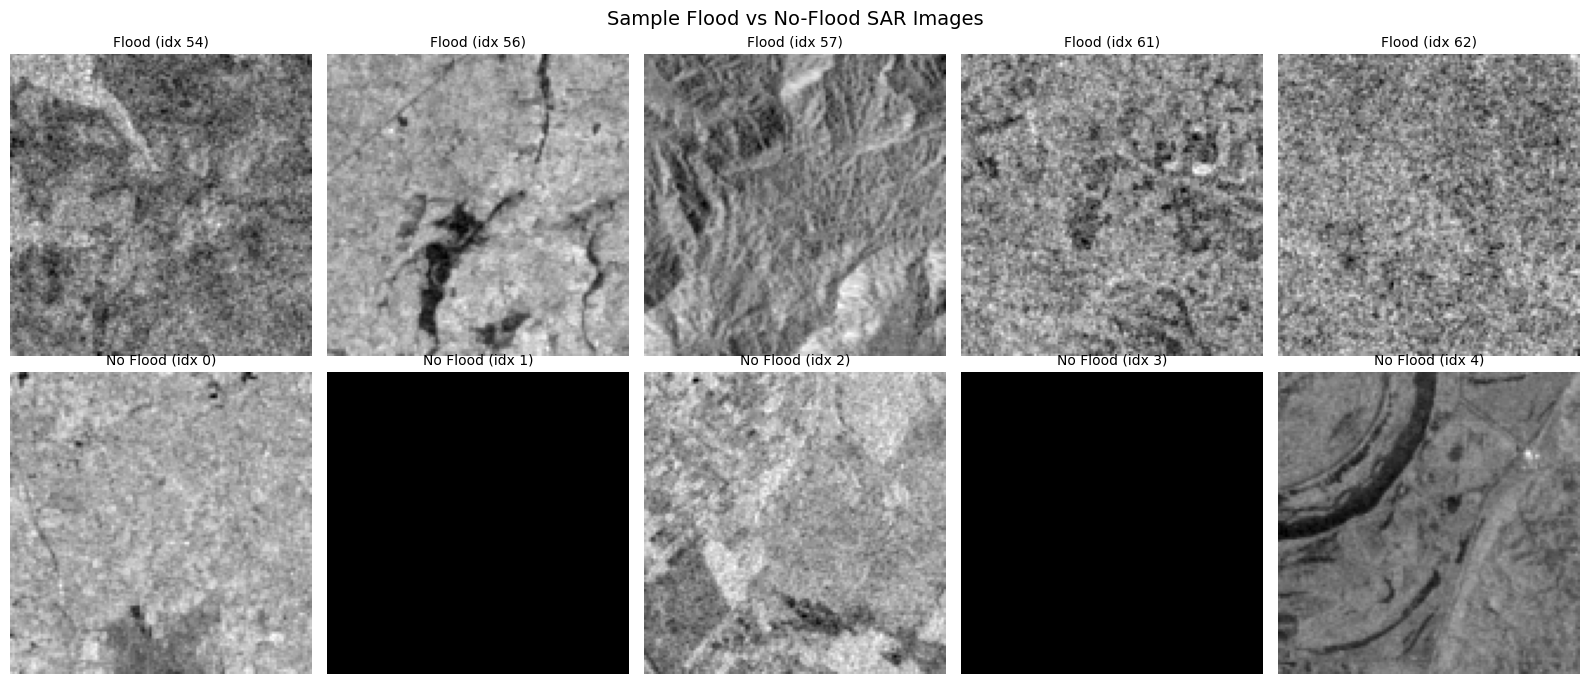

In [7]:
#visual check: sample Flood vs No-Flood images side by side
flood_examples = np.where(y_train == 1)[0][:5]
no_flood_examples = np.where(y_train == 0)[0][:5]

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for i, idx in enumerate(flood_examples):
    axes[0, i].imshow(X_train[idx].squeeze(), cmap="gray")
    axes[0, i].set_title(f"Flood (idx {idx})", fontsize=10)
    axes[0, i].axis("off")
for i, idx in enumerate(no_flood_examples):
    axes[1, i].imshow(X_train[idx].squeeze(), cmap="gray")
    axes[1, i].set_title(f"No Flood (idx {idx})", fontsize=10)
    axes[1, i].axis("off")
plt.suptitle("Sample Flood vs No-Flood SAR Images", fontsize=14)
plt.tight_layout()
plt.show()


Dark-pixel fraction (mean ± std)
  Flood    : 0.219 ± 0.329  (n=45)
  No Flood : 0.254 ± 0.323  (n=311)

Welch's t-test  t=-0.661  p=0.5115
-> NOT statistically distinguishable at p<0.05


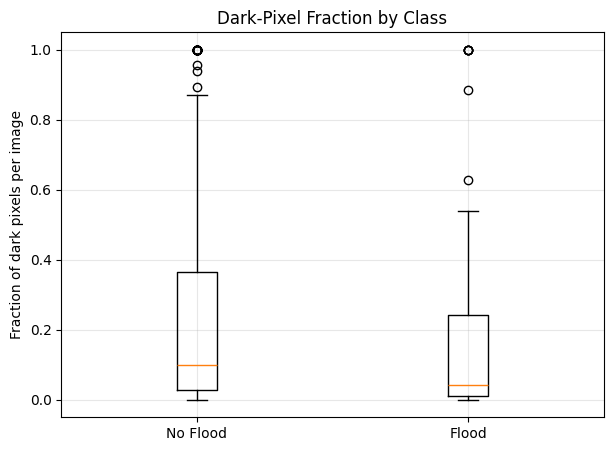

In [8]:
#quantitative check: dark-pixel fraction per image, grouped by label
#(flooded / open water tends to reflect radar away from the sensor -> appears dark in SAR)
DARK_THRESHOLD = np.percentile(X_train, 25)   # bottom 25% of all pixel values, dataset-wide

dark_fraction = (X_train.reshape(X_train.shape[0], -1) < DARK_THRESHOLD).mean(axis=1)

flood_dark = dark_fraction[y_train == 1]
no_flood_dark = dark_fraction[y_train == 0]

print("Dark-pixel fraction (mean ± std)")
print(f"  Flood    : {flood_dark.mean():.3f} ± {flood_dark.std():.3f}  (n={len(flood_dark)})")
print(f"  No Flood : {no_flood_dark.mean():.3f} ± {no_flood_dark.std():.3f}  (n={len(no_flood_dark)})")

from scipy import stats
t_stat, p_value = stats.ttest_ind(flood_dark, no_flood_dark, equal_var=False)
print(f"\nWelch's t-test  t={t_stat:.3f}  p={p_value:.4f}")
print("-> statistically distinguishable at p<0.05" if p_value < 0.05 else "-> NOT statistically distinguishable at p<0.05")

plt.figure(figsize=(7,5))
plt.boxplot([no_flood_dark, flood_dark], labels=["No Flood", "Flood"])
plt.ylabel("Fraction of dark pixels per image")
plt.title("Dark-Pixel Fraction by Class")
plt.grid(True, alpha=0.3)
plt.show()


### Data quality check — any corrupted / degenerate images?
`Flood (idx 62)` in the grid above rendered solid black — that looks like a corrupted tile or a no-data/masked region, not a real flood scene. With only 45 flood images total, even a couple of bad samples like this can distort both training and the statistics above. Flagging any near-constant images before trusting anything else.

Degenerate (near-constant) images found: 36 / 356
Indices: [1, 3, 12, 29, 32, 33, 70, 75, 77, 81, 90, 96, 100, 114, 118, 141, 150, 152, 154, 173, 177, 183, 201, 205, 217, 252, 257, 278, 298, 299, 300, 306, 309, 339, 344, 349]
Labels : [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0]   (1 = Flood, 0 = No Flood)


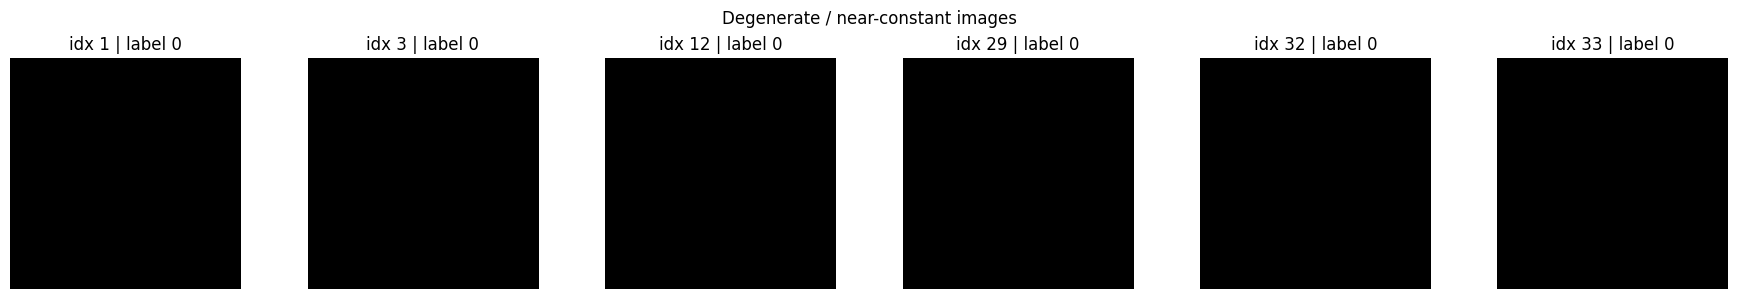

In [9]:
#flagging near-constant / degenerate images (e.g. solid black or solid uniform tiles)
per_image_std = X_train.reshape(X_train.shape[0], -1).std(axis=1)
DEGENERATE_STD_THRESHOLD = 0.01   # essentially no texture/variation at all

degenerate_idx = np.where(per_image_std < DEGENERATE_STD_THRESHOLD)[0]
print(f"Degenerate (near-constant) images found: {len(degenerate_idx)} / {len(X_train)}")
if len(degenerate_idx):
    print("Indices:", degenerate_idx.tolist())
    print("Labels :", y_train[degenerate_idx].tolist(), "  (1 = Flood, 0 = No Flood)")
    fig, axes = plt.subplots(1, min(len(degenerate_idx), 6), figsize=(3*min(len(degenerate_idx),6), 3))
    if len(degenerate_idx) == 1:
        axes = [axes]
    for ax, idx in zip(axes, degenerate_idx):
        ax.imshow(X_train[idx].squeeze(), cmap="gray")
        ax.set_title(f"idx {idx} | label {y_train[idx]}")
        ax.axis("off")
    plt.suptitle("Degenerate / near-constant images")
    plt.tight_layout()
    plt.show()


### Localized check — is flooding a small patch, not the whole scene?
A whole-image average dilutes a small flooded corner into near-invisibility. This checks each image's **darkest local block** instead of its overall average — if flooding shows up as a small dark patch, this should separate the classes even though the whole-image average didn't.

Darkest 16x16 block mean intensity (mean ± std)
  Flood    : 0.4110 ± 0.0919  (n=40)
  No Flood : 0.3692 ± 0.0994  (n=280)

Welch's t-test  t=2.636  p=0.0110
-> statistically distinguishable at p<0.05


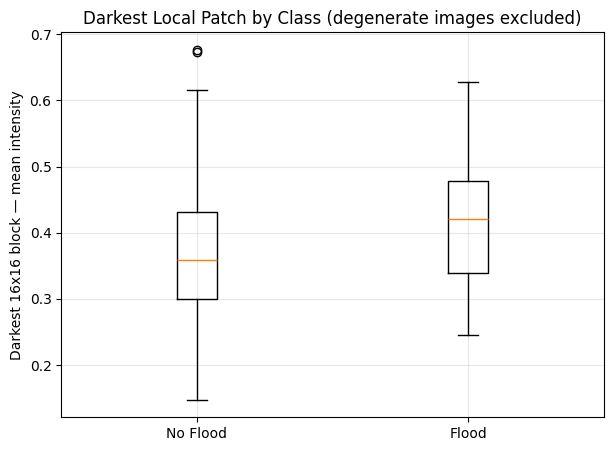

In [10]:
#localized dark-patch check: does the DARKEST block in each image differ by class?
BLOCK_SIZE = 16   # 128/16 = 8x8 = 64 blocks per image

def darkest_block_mean(img, block_size=BLOCK_SIZE):
    img2d = img.squeeze()
    h, w = img2d.shape
    block_means = [
        img2d[i:i+block_size, j:j+block_size].mean()
        for i in range(0, h, block_size)
        for j in range(0, w, block_size)
    ]
    return min(block_means)

#exclude the degenerate images found above so they don't skew this
clean_idx = np.setdiff1d(np.arange(len(X_train)), degenerate_idx)
darkest_block = np.array([darkest_block_mean(X_train[i]) for i in clean_idx])
clean_labels = y_train[clean_idx]

flood_darkest = darkest_block[clean_labels == 1]
no_flood_darkest = darkest_block[clean_labels == 0]

print("Darkest 16x16 block mean intensity (mean ± std)")
print(f"  Flood    : {flood_darkest.mean():.4f} ± {flood_darkest.std():.4f}  (n={len(flood_darkest)})")
print(f"  No Flood : {no_flood_darkest.mean():.4f} ± {no_flood_darkest.std():.4f}  (n={len(no_flood_darkest)})")

from scipy import stats
t_stat, p_value = stats.ttest_ind(flood_darkest, no_flood_darkest, equal_var=False)
print(f"\nWelch's t-test  t={t_stat:.3f}  p={p_value:.4f}")
print("-> statistically distinguishable at p<0.05" if p_value < 0.05 else "-> NOT statistically distinguishable at p<0.05")

plt.figure(figsize=(7,5))
plt.boxplot([no_flood_darkest, flood_darkest], labels=["No Flood", "Flood"])
plt.ylabel("Darkest 16x16 block — mean intensity")
plt.title("Darkest Local Patch by Class (degenerate images excluded)")
plt.grid(True, alpha=0.3)
plt.show()


### Remove the corrupted images — permanently
35/356 training images (and several in test) were solid black — sensor dropouts or no-data tiles, not real scenes. A handful were even mislabeled Flood, which is especially damaging given there were only 45 flood images to begin with. Dropping them from both train and test before anything else touches the data.

In [11]:
#checking X_test for the same corruption issue
per_image_std_test = X_test.reshape(X_test.shape[0], -1).std(axis=1)
degenerate_idx_test = np.where(per_image_std_test < DEGENERATE_STD_THRESHOLD)[0]
print(f"Degenerate (near-constant) images in X_test: {len(degenerate_idx_test)} / {len(X_test)}")
if len(degenerate_idx_test):
    print("Indices:", degenerate_idx_test.tolist())
    print("Labels :", y_test[degenerate_idx_test].tolist(), "  (1 = Flood, 0 = No Flood)")


Degenerate (near-constant) images in X_test: 9 / 90
Indices: [4, 31, 45, 49, 50, 66, 79, 80, 88]
Labels : [0, 1, 0, 0, 0, 0, 0, 1, 0]   (1 = Flood, 0 = No Flood)


In [12]:
#removing corrupted/degenerate images from both train and test sets, permanently
#(also filtering groups_train/groups_test the same way, so they stay aligned with X/y)
X_train = np.delete(X_train, degenerate_idx, axis=0)
y_train = np.delete(y_train, degenerate_idx, axis=0)
groups_train = np.delete(groups_train, degenerate_idx, axis=0)

X_test = np.delete(X_test, degenerate_idx_test, axis=0)
y_test = np.delete(y_test, degenerate_idx_test, axis=0)
groups_test = np.delete(groups_test, degenerate_idx_test, axis=0)

print("Cleaned Training Set :", X_train.shape, " Class distribution:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Cleaned Testing Set  :", X_test.shape, " Class distribution:", dict(zip(*np.unique(y_test, return_counts=True))))


Cleaned Training Set : (320, 128, 128, 1)  Class distribution: {np.int64(0): np.int64(280), np.int64(1): np.int64(40)}
Cleaned Testing Set  : (81, 128, 128, 1)  Class distribution: {np.int64(0): np.int64(72), np.int64(1): np.int64(9)}


### Switch to Group-Aware Stratified K-Fold Cross-Validation
The pretrained MobileNetV2 model jumped from AUC ~0.60 to ~0.86 — a large enough jump to be suspicious. With only 11 distinct flood events (countries) in this dataset, a rich ImageNet-pretrained feature extractor could achieve high accuracy by learning to recognize **regional terrain/urban style** rather than flooding itself — a well-known shortcut-learning failure mode. Plain `StratifiedKFold` can't catch this, since it only balances the flood/no-flood ratio per fold — it says nothing about keeping each country's images together, so chips from the same event could easily end up on both sides of the same fold.

This version uses **`StratifiedGroupKFold`** instead: every image from a given country stays entirely on one side of each fold, never split across train and test. If AUC holds up under this stricter test, the result is real. If it collapses back toward 0.6, the model was exploiting geography, not flooding.

**Caveat worth keeping in mind**: with only 11 groups total, this is a much coarser-grained split than before — expect noisier per-fold numbers than the row-level CV gave, purely because each fold's test set is now 2-3 whole countries' worth of images rather than a random sample of individual images.

In [13]:
#pooling all cleaned data - k-fold will split this, not a fixed train/test split
from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit
from sklearn.metrics import roc_auc_score, roc_curve, auc

X_all = np.concatenate([X_train, X_test], axis=0)
y_all = np.concatenate([y_train, y_test], axis=0)
groups_all = np.concatenate([groups_train, groups_test], axis=0)

#no autoencoder needed for this version - the pretrained MobileNetV2 backbone
#(built fresh in build_pretrained_model below) replaces it entirely

print("Pooled dataset :", X_all.shape)
print("Class distribution:", dict(zip(*np.unique(y_all, return_counts=True))))
print("Group (country) distribution:", dict(zip(*np.unique(groups_all, return_counts=True))))


Pooled dataset : (401, 128, 128, 1)
Class distribution: {np.int64(0): np.int64(352), np.int64(1): np.int64(49)}
Group (country) distribution: {np.str_('Bolivia'): np.int64(7), np.str_('Ghana'): np.int64(47), np.str_('India'): np.int64(61), np.str_('Mekong'): np.int64(28), np.str_('Nigeria'): np.int64(15), np.str_('Pakistan'): np.int64(27), np.str_('Paraguay'): np.int64(61), np.str_('Somalia'): np.int64(24), np.str_('Spain'): np.int64(30), np.str_('Sri-Lanka'): np.int64(41), np.str_('USA'): np.int64(60)}


### Reusable building blocks
Same transformer architecture as before (PositionEmbedding, transformer block) — only the feature extractor changes. Instead of a small conv autoencoder trained from scratch, `build_pretrained_model()` uses **MobileNetV2 pretrained on ImageNet** as the encoder. Your SAR images are single-channel; MobileNetV2 expects 3-channel RGB, so the single band gets tiled into 3 identical channels before going in — this happens inside the model graph itself, so nothing about your saved `.npy` files changes.

In [14]:
#positional embedding layer
class PositionEmbedding(layers.Layer):
    def __init__(self, sequence_length, embed_dim):
        super().__init__()
        self.position_embedding = layers.Embedding(
            input_dim=sequence_length,
            output_dim=embed_dim
        )
    def call(self, inputs):
        positions = tf.range(start=0,
                             limit=tf.shape(inputs)[1],
                             delta=1)
        embedded_positions = self.position_embedding(positions)
        return inputs + embedded_positions


In [15]:
#transformer block, 2 heads, 1 block
def transformer_block(inputs):
    x = layers.LayerNormalization()(inputs)
    attention = layers.MultiHeadAttention(
        num_heads=2,
        key_dim=32
    )(x, x)
    x = layers.Add()([inputs, attention])
    y = layers.LayerNormalization()(x)
    y = layers.Dense(
        64,
        activation="relu"
    )(y)
    y = layers.Dense(32)(y)
    return layers.Add()([x, y])


In [16]:
#tokens produced by MobileNetV2's feature map: 128x128 input -> 4x4x1280
#(fewer tokens than the autoencoder version, but far richer per token)
NUM_TOKENS = 4 * 4
FEATURE_DIM = 1280

def build_pretrained_model():
    inputs = layers.Input(shape=(128, 128, 1))
    x = layers.Concatenate()([inputs, inputs, inputs])   # fake RGB: (128,128,1) -> (128,128,3)
    x = layers.Lambda(lambda t: t * 2.0 - 1.0)(x)        # our data is [0,1] -> rescale to [-1,1]

    backbone = tf.keras.applications.MobileNetV2(
        input_shape=(128, 128, 3),
        include_top=False,
        weights="imagenet"
    )

    features = backbone(x)                                        # (None, 4, 4, 1280)
    tokens = layers.Reshape((NUM_TOKENS, FEATURE_DIM))(features)   # (None, 16, 1280)
    y = layers.Dense(32)(tokens)
    y = PositionEmbedding(NUM_TOKENS, 32)(y)
    y = transformer_block(y)
    y = layers.GlobalAveragePooling1D()(y)
    y = layers.Dense(64, activation="relu")(y)
    y = layers.Dropout(0.3)(y)
    outputs = layers.Dense(1, activation="sigmoid")(y)

    model = Model(inputs, outputs)
    return model, backbone


In [17]:
#augmentation helper - applied only to the training portion inside each fold
from skimage.transform import resize

AUGMENTATIONS_PER_FLOOD_IMAGE = 6  # bumped from 4 - each augmentation now varies more, so a few extra copies helps

def augment_image(img):
    aug = img.copy()

    # --- geometric: flips + 90-degree rotations (unchanged from before) ---
    if np.random.rand() < 0.5:
        aug = np.fliplr(aug)
    if np.random.rand() < 0.5:
        aug = np.flipud(aug)
    k = np.random.choice([0, 1, 2, 3])
    aug = np.rot90(aug, k)

    # --- random crop + resize back (simulates slight zoom / framing shift) ---
    if np.random.rand() < 0.5:
        h, w = aug.shape[:2]
        crop_frac = np.random.uniform(0.85, 0.98)
        ch, cw = int(h * crop_frac), int(w * crop_frac)
        top = np.random.randint(0, h - ch + 1)
        left = np.random.randint(0, w - cw + 1)
        aug = aug[top:top + ch, left:left + cw]
        aug = resize(aug, (h, w), anti_aliasing=True)

    # --- multiplicative speckle noise (matches SAR backscatter noise statistics) ---
    if np.random.rand() < 0.7:
        sigma = np.random.uniform(0.02, 0.08)
        speckle = np.random.normal(loc=1.0, scale=sigma, size=aug.shape)
        aug = aug * speckle

    # --- mild intensity / gamma jitter ---
    if np.random.rand() < 0.5:
        gamma = np.random.uniform(0.85, 1.15)
        aug = np.power(np.clip(aug, 0, 1), gamma)

    # keep values in the valid [0,1] range the rest of the pipeline expects
    aug = np.clip(aug, 0.0, 1.0)

    return aug

In [18]:
#callbacks factory - each phase, in each fold, gets its own fresh instances
def make_callbacks(checkpoint_name, es_patience=8):
    checkpoint = ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, checkpoint_name),
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=0
    )
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=es_patience,
        restore_best_weights=True,
        verbose=0
    )
    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=0
    )
    return [checkpoint, early_stop, reduce_lr]


### Baseline check — latent space separability before any training
Same diagnostic as before, run once up front on the full pooled dataset with a freshly loaded, untouched encoder.

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


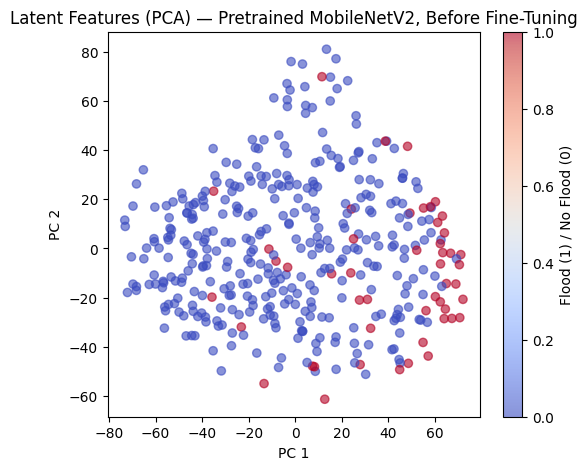

In [19]:
#baseline latent features on the pooled dataset, backbone exactly as pretrained on ImageNet
from sklearn.decomposition import PCA

_baseline_inputs = layers.Input(shape=(128, 128, 1))
_baseline_x = layers.Concatenate()([_baseline_inputs, _baseline_inputs, _baseline_inputs])
_baseline_x = layers.Lambda(lambda t: t * 2.0 - 1.0)(_baseline_x)
_baseline_backbone = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3), include_top=False, weights="imagenet"
)
_baseline_encoder = Model(_baseline_inputs, _baseline_backbone(_baseline_x))

baseline_features = _baseline_encoder.predict(X_all, batch_size=16, verbose=0)
flat_baseline = baseline_features.reshape(baseline_features.shape[0], -1)
pca_before = PCA(n_components=2).fit_transform(flat_baseline)

plt.figure(figsize=(6,5))
scatter = plt.scatter(pca_before[:, 0], pca_before[:, 1], c=y_all, cmap="coolwarm", alpha=0.6)
plt.title("Latent Features (PCA) — Pretrained MobileNetV2, Before Fine-Tuning")
plt.xlabel("PC 1"); plt.ylabel("PC 2")
plt.colorbar(scatter, label="Flood (1) / No Flood (0)")
plt.show()


### Per-fold training function
Everything one fold needs to do: split its training portion further into sub-train/val (val is used for early stopping and threshold tuning, never for augmentation), augment only the sub-train flood images, build a **fresh** pretrained backbone + model, run Phase 1 (backbone frozen) then Phase 2 (unfreeze the last `unfreeze_last_n` layers of the backbone and fine-tune at a low LR), tune the decision threshold, and — if given a test set — evaluate on it. When `test_idx` is omitted, this trains on everything with no held-out evaluation, which is what the final deployment run at the bottom uses.

In [20]:
def run_one_fold(fold_label, train_idx, test_idx=None, phase1_epochs=25, phase2_epochs=40, save_model_path=None, finetune=True, unfreeze_last_n=20):
    X_fold_raw = X_all[train_idx]
    y_fold_raw = y_all[train_idx]
    groups_fold = groups_all[train_idx]

    #internal split: sub-train / val (val used for early stopping + threshold tuning)
    #group-aware: no country appears in both sub-train and val either
    gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
    tr_idx, val_idx = next(gss.split(X_fold_raw, y_fold_raw, groups_fold))
    X_tr_raw, X_val_raw = X_fold_raw[tr_idx], X_fold_raw[val_idx]
    y_tr_raw, y_val_raw = y_fold_raw[tr_idx], y_fold_raw[val_idx]

    #augment the training portion only
    flood_idx = np.where(y_tr_raw == 1)[0]
    aug_imgs, aug_labels = [], []
    for idx in flood_idx:
        for _ in range(AUGMENTATIONS_PER_FLOOD_IMAGE):
            aug_imgs.append(augment_image(X_tr_raw[idx]))
            aug_labels.append(1)
    if aug_imgs:
        X_tr_raw = np.concatenate([X_tr_raw, np.array(aug_imgs)], axis=0)
        y_tr_raw = np.concatenate([y_tr_raw, np.array(aug_labels)], axis=0)

    classes = np.unique(y_tr_raw)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_tr_raw)
    class_weights = dict(zip(classes, weights))

    #fresh model + fresh pretrained backbone for this fold
    model, backbone = build_pretrained_model()

    #phase 1: backbone frozen
    backbone.trainable = False
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC(name="auc")]
    )
    history_phase1 = model.fit(
        X_tr_raw, y_tr_raw,
        validation_data=(X_val_raw, y_val_raw),
        epochs=phase1_epochs,
        batch_size=16,
        class_weight=class_weights,
        callbacks=make_callbacks(f"{fold_label}_phase1.keras", es_patience=6),
        shuffle=True,
        verbose=0
    )

    #phase 2: unfreeze the last N layers of the backbone, fine-tune at a low LR
    #(skipped for the frozen-only ablation)
    if finetune:
        backbone.trainable = True
        for layer in backbone.layers[:-unfreeze_last_n]:
            layer.trainable = False
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
            loss="binary_crossentropy",
            metrics=["accuracy", tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC(name="auc")]
        )
        history_phase2 = model.fit(
            X_tr_raw, y_tr_raw,
            validation_data=(X_val_raw, y_val_raw),
            epochs=phase2_epochs,
            batch_size=16,
            class_weight=class_weights,
            callbacks=make_callbacks(f"{fold_label}_phase2.keras", es_patience=8),
            shuffle=True,
            verbose=0
        )
        merged_history = {
            key: history_phase1.history[key] + history_phase2.history.get(key, [])
            for key in history_phase1.history
        }
    else:
        merged_history = dict(history_phase1.history)

    #tune the decision threshold on the (clean, unaugmented) validation split
    val_probs = model.predict(X_val_raw, verbose=0).flatten()
    candidate_thresholds = np.arange(0.05, 0.95, 0.01)
    best_threshold, best_f1 = 0.5, -1
    for t in candidate_thresholds:
        preds = (val_probs >= t).astype(int)
        score = f1_score(y_val_raw, preds, zero_division=0)
        if score > best_f1:
            best_f1, best_threshold = score, t

    result = {
        "fold": fold_label,
        "best_threshold": best_threshold,
        "val_f1": best_f1,
        "history": merged_history,
        "phase1_epochs_ran": len(history_phase1.history["loss"]),
        "model": model,
        "encoder": backbone
    }

    if save_model_path:
        model.save(save_model_path)

    if test_idx is not None and len(test_idx) > 0:
        X_test_fold = X_all[test_idx]
        y_test_fold = y_all[test_idx]
        test_probs = model.predict(X_test_fold, verbose=0).flatten()
        test_preds = (test_probs >= best_threshold).astype(int)
        result["test_idx"] = test_idx
        result["y_prob"] = test_probs
        result["y_pred"] = test_preds
        result["accuracy"] = accuracy_score(y_test_fold, test_preds)
        result["precision"] = precision_score(y_test_fold, test_preds, zero_division=0)
        result["recall"] = recall_score(y_test_fold, test_preds, zero_division=0)
        result["f1"] = f1_score(y_test_fold, test_preds, zero_division=0)
        try:
            result["auc"] = roc_auc_score(y_test_fold, test_probs)
        except ValueError:
            result["auc"] = float("nan")

    return result


### Run 5-fold stratified cross-validation
Every image in the pooled dataset ends up in exactly one fold's held-out test set. This will take a while — 5 folds, each running the full Phase 1 + Phase 2 training.

In [21]:
#running 5-fold GROUP-AWARE stratified cross-validation
N_FOLDS = 5
skf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

fold_results = []
for fold_num, (train_idx, test_idx) in enumerate(skf.split(X_all, y_all, groups_all), start=1):
    test_countries = sorted(set(groups_all[test_idx]))
    print("="*70)
    print(f"FOLD {fold_num}/{N_FOLDS}  (held-out countries: {test_countries})")
    print("="*70)
    res = run_one_fold(f"pretrained_fold{fold_num}", train_idx, test_idx)
    fold_results.append(res)
    print(
        f"Fold {fold_num} -> accuracy={res['accuracy']:.3f}  "
        f"flood_precision={res['precision']:.3f}  flood_recall={res['recall']:.3f}  "
        f"flood_f1={res['f1']:.3f}  auc={res['auc']:.3f}  threshold={res['best_threshold']:.2f}  "
        f"(phase1 ran {res['phase1_epochs_ran']} epochs)"
    )


FOLD 1/5  (held-out countries: [np.str_('Bolivia'), np.str_('Mekong')])
Fold 1 -> accuracy=0.686  flood_precision=0.154  flood_recall=1.000  flood_f1=0.267  auc=0.985  threshold=0.24  (phase1 ran 25 epochs)
FOLD 2/5  (held-out countries: [np.str_('Nigeria'), np.str_('Pakistan')])


Fold 2 -> accuracy=0.714  flood_precision=0.250  flood_recall=0.250  flood_f1=0.250  auc=0.581  threshold=0.73  (phase1 ran 14 epochs)
FOLD 3/5  (held-out countries: [np.str_('Somalia'), np.str_('USA')])
Fold 3 -> accuracy=0.714  flood_precision=0.115  flood_recall=0.750  flood_f1=0.200  auc=0.778  threshold=0.68  (phase1 ran 22 epochs)
FOLD 4/5  (held-out countries: [np.str_('India'), np.str_('Spain')])
Fold 4 -> accuracy=0.890  flood_precision=0.000  flood_recall=0.000  flood_f1=0.000  auc=0.646  threshold=0.73  (phase1 ran 19 epochs)
FOLD 5/5  (held-out countries: [np.str_('Ghana'), np.str_('Paraguay'), np.str_('Sri-Lanka')])
Fold 5 -> accuracy=0.785  flood_precision=0.513  flood_recall=0.606  flood_f1=0.556  auc=0.786  threshold=0.75  (phase1 ran 18 epochs)


### Aggregate out-of-fold results — this is the trustworthy evaluation
Every image gets exactly one out-of-fold prediction (made by a model that never saw it during training). This is a much more reliable estimate of real-world performance than any single train/test split.

In [22]:
#reconstructing out-of-fold predictions, aligned to the original X_all/y_all indices
y_pred_all = np.zeros(len(y_all), dtype=int)
y_prob_all = np.zeros(len(y_all), dtype=float)
for res in fold_results:
    y_pred_all[res["test_idx"]] = res["y_pred"]
    y_prob_all[res["test_idx"]] = res["y_prob"]

print(
    classification_report(
        y_all,
        y_pred_all,
        target_names=["No Flood", "Flood"],
        zero_division=0
    )
)


              precision    recall  f1-score   support

    No Flood       0.93      0.81      0.86       352
       Flood       0.29      0.55      0.38        49

    accuracy                           0.78       401
   macro avg       0.61      0.68      0.62       401
weighted avg       0.85      0.78      0.81       401



[[285  67]
 [ 22  27]]


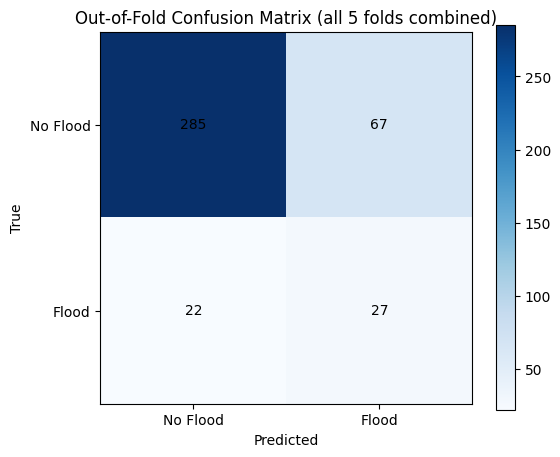

In [23]:
#confusion matrix (out-of-fold)
cm = confusion_matrix(y_all, y_pred_all)
print(cm)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.title("Out-of-Fold Confusion Matrix (all 5 folds combined)")
plt.colorbar()
plt.xticks([0,1], ["No Flood","Flood"])
plt.yticks([0,1], ["No Flood","Flood"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center", color="black")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()


Out-of-fold ROC AUC : 0.7575


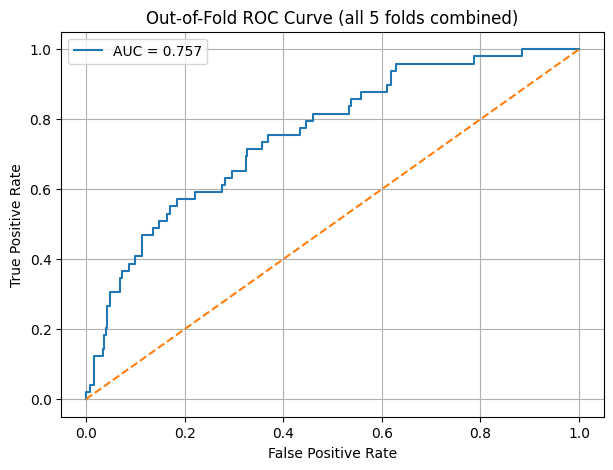

In [24]:
# ============================================================
# Out-of-fold ROC Curve
# ============================================================
fpr, tpr, _ = roc_curve(y_all, y_prob_all)
roc_auc = auc(fpr, tpr)
print(f"Out-of-fold ROC AUC : {roc_auc:.4f}")

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Out-of-Fold ROC Curve (all 5 folds combined)")
plt.legend()
plt.grid(True)
plt.show()


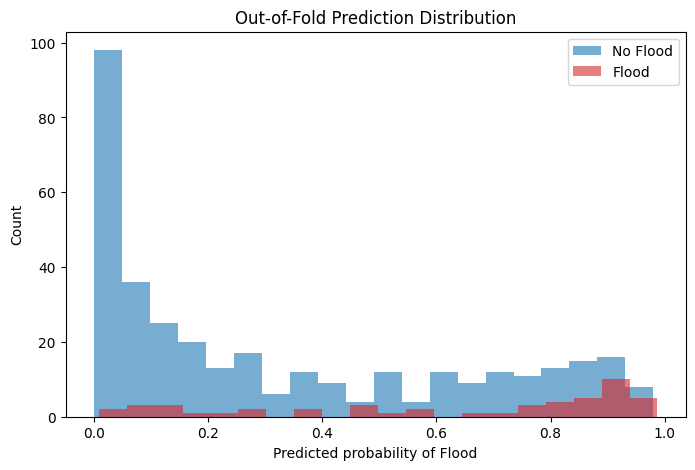

In [25]:
#out-of-fold prediction distribution
plt.figure(figsize=(8,5))
plt.hist(y_prob_all[y_all==0], bins=20, alpha=0.6, label="No Flood", color="tab:blue")
plt.hist(y_prob_all[y_all==1], bins=20, alpha=0.6, label="Flood", color="tab:red")
plt.xlabel("Predicted probability of Flood")
plt.ylabel("Count")
plt.title("Out-of-Fold Prediction Distribution")
plt.legend()
plt.show()


### Per-fold metrics — how much does performance vary fold to fold?
The aggregate numbers above tell you overall performance; this table tells you how stable that performance is. A small std across folds means the model is consistently OK (or consistently bad); a large std means results are sensitive to which images happen to be in the training set — worth knowing either way.

In [26]:
#per-fold metrics summary
fold_summary = pd.DataFrame([
    {
        "fold": r["fold"],
        "threshold": r["best_threshold"],
        "accuracy": r["accuracy"],
        "flood_precision": r["precision"],
        "flood_recall": r["recall"],
        "flood_f1": r["f1"],
        "auc": r["auc"]
    }
    for r in fold_results
])
print(fold_summary.to_string(index=False))
print()
print("Mean ± Std across folds:")
for col in ["accuracy", "flood_precision", "flood_recall", "flood_f1", "auc"]:
    print(f"  {col:16s}: {fold_summary[col].mean():.3f} ± {fold_summary[col].std():.3f}")


            fold  threshold  accuracy  flood_precision  flood_recall  flood_f1      auc
pretrained_fold1       0.24  0.685714         0.153846      1.000000  0.266667 0.984848
pretrained_fold2       0.73  0.714286         0.250000      0.250000  0.250000 0.580882
pretrained_fold3       0.68  0.714286         0.115385      0.750000  0.200000 0.778125
pretrained_fold4       0.73  0.890110         0.000000      0.000000  0.000000 0.646067
pretrained_fold5       0.75  0.785235         0.512821      0.606061  0.555556 0.785789

Mean ± Std across folds:
  accuracy        : 0.758 ± 0.083
  flood_precision : 0.206 ± 0.193
  flood_recall    : 0.521 ± 0.398
  flood_f1        : 0.254 ± 0.199
  auc             : 0.755 ± 0.155


### Visualize sample out-of-fold predictions

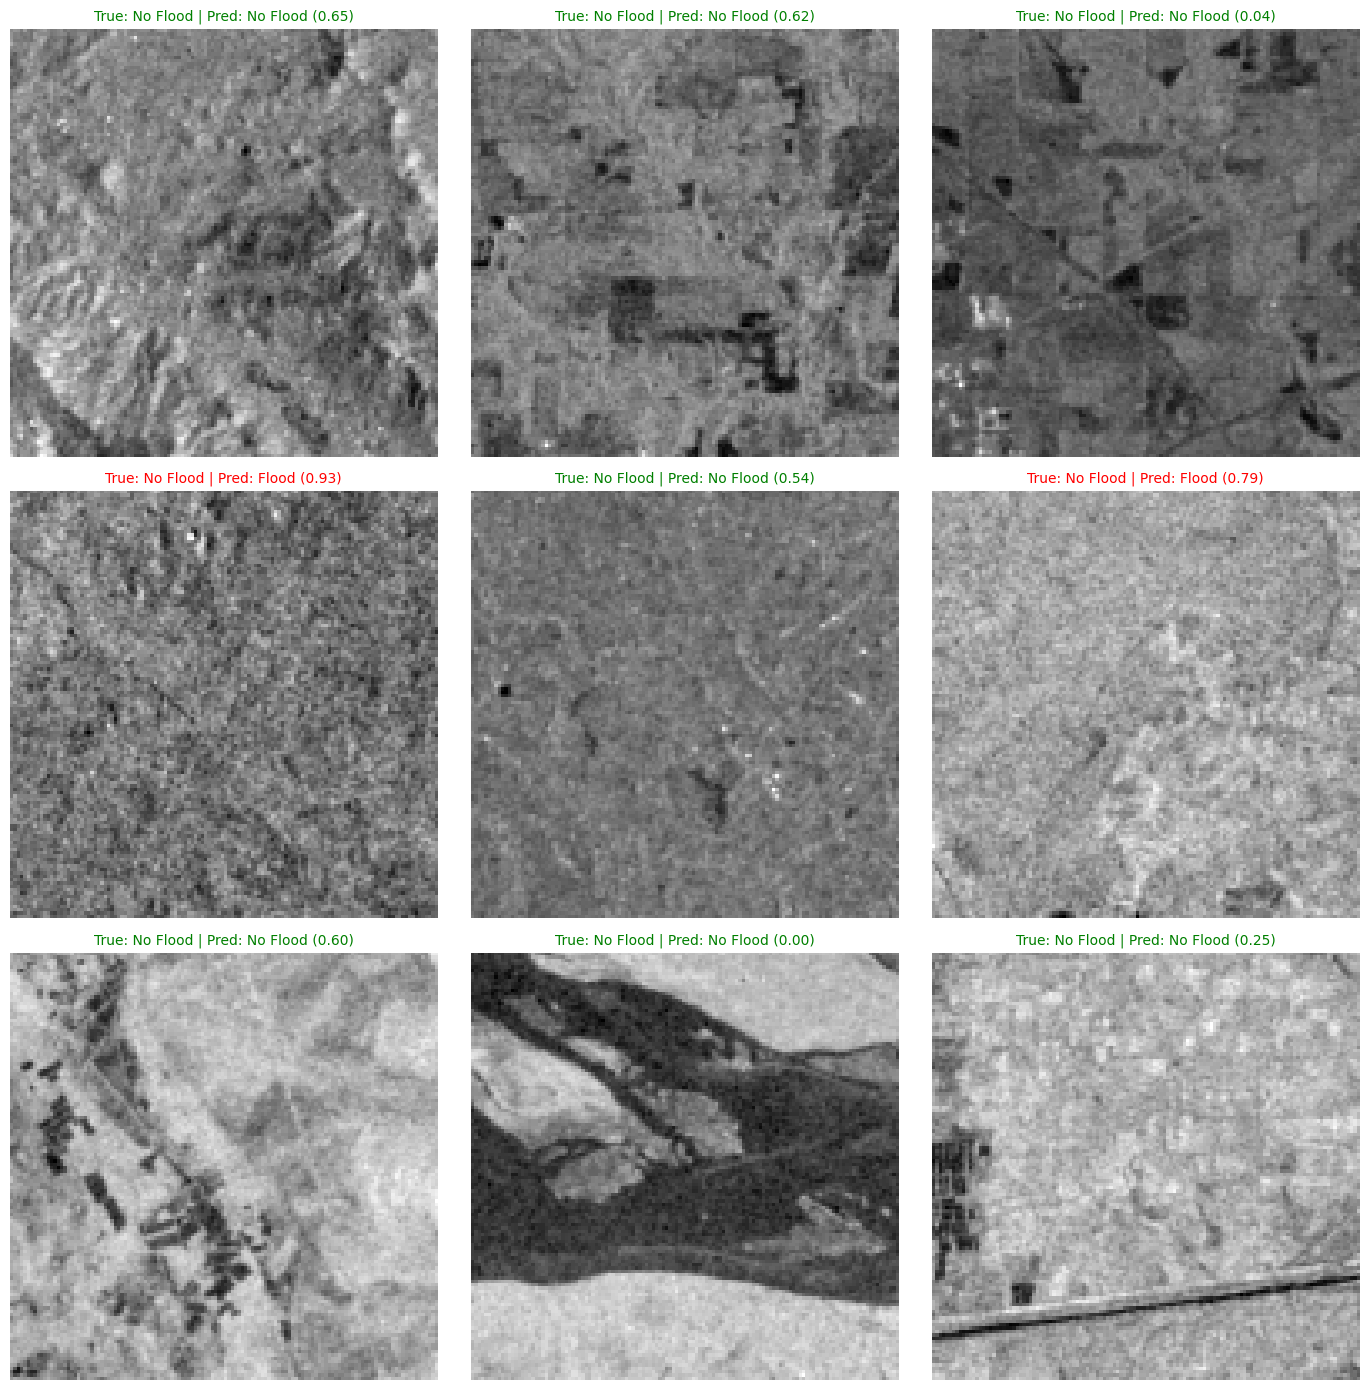

In [27]:
#visualize random out-of-fold predictions
num_samples = 9
sample_indices = np.random.choice(len(X_all), num_samples, replace=False)

plt.figure(figsize=(14,14))
for i, idx in enumerate(sample_indices):
    plt.subplot(3, 3, i+1)
    plt.imshow(X_all[idx].squeeze(), cmap="gray")
    true_label = "Flood" if y_all[idx] == 1 else "No Flood"
    pred_label = "Flood" if y_pred_all[idx] == 1 else "No Flood"
    color = "green" if true_label == pred_label else "red"
    plt.title(f"True: {true_label} | Pred: {pred_label} ({y_prob_all[idx]:.2f})", color=color, fontsize=10)
    plt.axis("off")
plt.tight_layout()
plt.show()


### Final step — train the deployment model on ALL data
Cross-validation told us how well this approach generalizes — it does **not** produce a single deployable model, since each fold's model only saw 80% of the data. This trains one more time on the full cleaned dataset.

**Defaulting to `finetune=True` here** (unlike the autoencoder version, where the ablation showed fine-tuning didn't help) — pretrained ImageNet backbones often *do* benefit from fine-tuning, even on small downstream datasets, since they're starting from much stronger general-purpose features than a from-scratch autoencoder was. Check the fine-tune-vs-frozen ablation further below once it's run, and flip this to `False` if frozen-only turns out to win here too.

In [28]:
#training the final deployment model on all cleaned data
#UPDATED: both the group-aware ablation runs showed fine-tuned vs frozen are
#statistically tied (overlapping std) - going with frozen: equally good, simpler, faster
print("Training final pretrained-backbone deployment model on ALL cleaned data (frozen)...")
final_result = run_one_fold(
    "pretrained_final_deployment",
    train_idx=np.arange(len(X_all)),
    test_idx=None,
    finetune=False,
    save_model_path=os.path.join(MODEL_DIR, "simple_transformer_pretrained_final.keras")
)

FINAL_THRESHOLD = final_result["best_threshold"]
print(f"Final model saved to simple_transformer_pretrained_final.keras")
print(f"Internal validation F1 at tuned threshold : {final_result['val_f1']:.4f}")
print(f"Tuned decision threshold                  : {FINAL_THRESHOLD:.2f}")
print(f"\nUse this threshold ({FINAL_THRESHOLD:.2f}) in app.py if this model gets deployed.")


Training final pretrained-backbone deployment model on ALL cleaned data (frozen)...
Final model saved to simple_transformer_pretrained_final.keras
Internal validation F1 at tuned threshold : 0.4000
Tuned decision threshold                  : 0.13

Use this threshold (0.13) in app.py if this model gets deployed.


KeyError: 'precision'

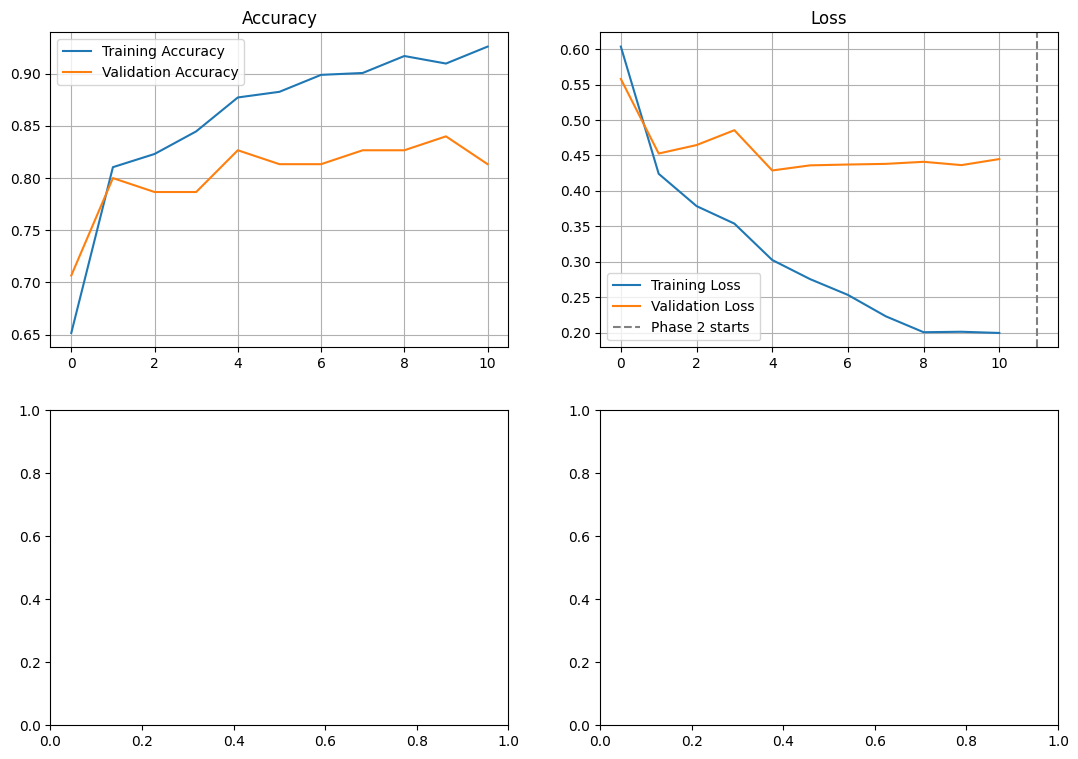

In [29]:
#training curves for the final deployment run
history = final_result["history"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0,0].plot(history["accuracy"], label="Training Accuracy")
axes[0,0].plot(history["val_accuracy"], label="Validation Accuracy")
axes[0,0].set_title("Accuracy"); axes[0,0].legend(); axes[0,0].grid(True)

axes[0,1].plot(history["loss"], label="Training Loss")
axes[0,1].plot(history["val_loss"], label="Validation Loss")
axes[0,1].axvline(final_result["phase1_epochs_ran"], linestyle="--", color="gray", label="Phase 2 starts")
axes[0,1].set_title("Loss"); axes[0,1].legend(); axes[0,1].grid(True)

axes[1,0].plot(history["precision"], label="Training Precision")
axes[1,0].plot(history["val_precision"], label="Validation Precision")
axes[1,0].set_title("Precision"); axes[1,0].legend(); axes[1,0].grid(True)

axes[1,1].plot(history["recall"], label="Training Recall")
axes[1,1].plot(history["val_recall"], label="Validation Recall")
axes[1,1].set_title("Recall"); axes[1,1].legend(); axes[1,1].grid(True)

plt.tight_layout()
plt.show()


### Post-training check — final deployment encoder
Same PCA diagnostic as the baseline, now using the backbone from the final deployment model. If `finetune=True` was used above, compare this against the baseline PCA plot to see whether fine-tuning actually pulled Flood and No-Flood further apart — if `finetune=False` was used instead, expect this to look essentially identical to the baseline.

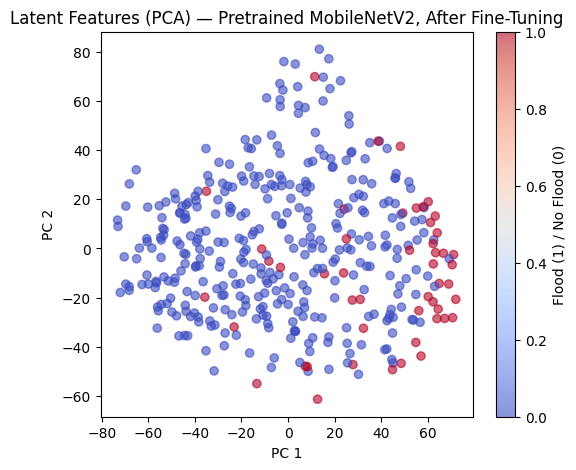

In [31]:
#latent features after fine-tuning, using the final deployment model's backbone
finetuned_backbone = final_result["encoder"]
_post_inputs = layers.Input(shape=(128, 128, 1))
_post_x = layers.Concatenate()([_post_inputs, _post_inputs, _post_inputs])
_post_x = layers.Lambda(lambda t: t * 2.0 - 1.0)(_post_x)
_post_encoder = Model(_post_inputs, finetuned_backbone(_post_x))

finetuned_features = _post_encoder.predict(X_all, batch_size=16, verbose=0)
flat_finetuned = finetuned_features.reshape(finetuned_features.shape[0], -1)
pca_after = PCA(n_components=2).fit_transform(flat_finetuned)

plt.figure(figsize=(6,5))
scatter = plt.scatter(pca_after[:, 0], pca_after[:, 1], c=y_all, cmap="coolwarm", alpha=0.6)
plt.title("Latent Features (PCA) — Pretrained MobileNetV2, After Fine-Tuning")
plt.xlabel("PC 1"); plt.ylabel("PC 2")
plt.colorbar(scatter, label="Flood (1) / No Flood (0)")
plt.show()


In [32]:
#final summary
print("="*70)
print("K-Fold Cross-Validated, Pretrained MobileNetV2 + Transformer Pipeline Completed")
print("="*70)
print()
print(f"Out-of-fold accuracy       : {accuracy_score(y_all, y_pred_all):.3f}")
print(f"Out-of-fold flood F1       : {f1_score(y_all, y_pred_all, zero_division=0):.3f}")
print(f"Out-of-fold ROC AUC        : {roc_auc:.3f}")
print(f"Mean per-fold flood recall : {fold_summary['flood_recall'].mean():.3f} ± {fold_summary['flood_recall'].std():.3f}")
print()
print("Deployment model saved as  : simple_transformer_pretrained_final.keras")
print(f"Use decision threshold     : {FINAL_THRESHOLD:.2f}  (not 0.5)")
print()
print("Compare this out-of-fold AUC against the single-band custom-autoencoder")
print("model's (~0.59-0.60) to see whether ImageNet pretraining actually helped.")
print("="*70)
print("Notebook 7 (Pretrained Backbone) Completed Successfully!")
print("="*70)


K-Fold Cross-Validated, Pretrained MobileNetV2 + Transformer Pipeline Completed

Out-of-fold accuracy       : 0.778
Out-of-fold flood F1       : 0.378
Out-of-fold ROC AUC        : 0.757
Mean per-fold flood recall : 0.521 ± 0.398

Deployment model saved as  : simple_transformer_pretrained_final.keras
Use decision threshold     : 0.13  (not 0.5)

Compare this out-of-fold AUC against the single-band custom-autoencoder
model's (~0.59-0.60) to see whether ImageNet pretraining actually helped.
Notebook 7 (Pretrained Backbone) Completed Successfully!


### Ablation — is fine-tuning actually earning its keep?
Earlier fine-tune-vs-frozen comparisons were made on a single split that was still dirty at the time, so they weren't a fair test. Now that we have a proper CV harness and clean data, rerun the **exact same 5 folds** (same `random_state`, so fold membership is identical) with Phase 2 turned off — encoder stays frozen the whole time — and compare directly against the fine-tuned results above.

In [33]:
#ablation: identical 5 GROUP-AWARE folds, but the encoder stays frozen throughout (no Phase 2)
skf_ablation = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

frozen_fold_results = []
for fold_num, (train_idx, test_idx) in enumerate(skf_ablation.split(X_all, y_all, groups_all), start=1):
    print("="*70)
    print(f"[FROZEN-ONLY] FOLD {fold_num}/{N_FOLDS}")
    print("="*70)
    res = run_one_fold(f"pretrained_frozen_fold{fold_num}", train_idx, test_idx, finetune=False)
    frozen_fold_results.append(res)
    print(
        f"Fold {fold_num} -> accuracy={res['accuracy']:.3f}  "
        f"flood_precision={res['precision']:.3f}  flood_recall={res['recall']:.3f}  "
        f"flood_f1={res['f1']:.3f}  auc={res['auc']:.3f}  threshold={res['best_threshold']:.2f}"
    )


[FROZEN-ONLY] FOLD 1/5
Fold 1 -> accuracy=0.714  flood_precision=0.167  flood_recall=1.000  flood_f1=0.286  auc=0.879  threshold=0.16
[FROZEN-ONLY] FOLD 2/5
Fold 2 -> accuracy=0.786  flood_precision=0.000  flood_recall=0.000  flood_f1=0.000  auc=0.618  threshold=0.83
[FROZEN-ONLY] FOLD 3/5
Fold 3 -> accuracy=0.738  flood_precision=0.091  flood_recall=0.500  flood_f1=0.154  auc=0.803  threshold=0.75
[FROZEN-ONLY] FOLD 4/5
Fold 4 -> accuracy=0.846  flood_precision=0.071  flood_recall=0.500  flood_f1=0.125  auc=0.871  threshold=0.54
[FROZEN-ONLY] FOLD 5/5
Fold 5 -> accuracy=0.792  flood_precision=0.625  flood_recall=0.152  flood_f1=0.244  auc=0.743  threshold=0.82


In [35]:
#aggregated out-of-fold report for the frozen-only ablation
y_pred_frozen = np.zeros(len(y_all), dtype=int)
y_prob_frozen = np.zeros(len(y_all), dtype=float)
for res in frozen_fold_results:
    y_pred_frozen[res["test_idx"]] = res["y_pred"]
    y_prob_frozen[res["test_idx"]] = res["y_prob"]

print("=== Frozen-Encoder (no fine-tuning) - Out-of-Fold Report ===")
print(
    classification_report(
        y_all,
        y_pred_frozen,
        target_names=["No Flood", "Flood"],
        zero_division=0
    )
)

fpr_frozen, tpr_frozen, _ = roc_curve(y_all, y_prob_frozen)
auc_frozen = auc(fpr_frozen, tpr_frozen)
print(f"Frozen-encoder out-of-fold ROC AUC : {auc_frozen:.4f}")


=== Frozen-Encoder (no fine-tuning) - Out-of-Fold Report ===
              precision    recall  f1-score   support

    No Flood       0.89      0.87      0.88       352
       Flood       0.18      0.20      0.19        49

    accuracy                           0.79       401
   macro avg       0.53      0.54      0.53       401
weighted avg       0.80      0.79      0.79       401

Frozen-encoder out-of-fold ROC AUC : 0.7234


### Fine-tuned vs. frozen-only — side by side

In [36]:
#side-by-side comparison: fine-tuned vs frozen-only, same 5 folds
frozen_summary = pd.DataFrame([
    {
        "fold": r["fold"],
        "accuracy": r["accuracy"],
        "flood_precision": r["precision"],
        "flood_recall": r["recall"],
        "flood_f1": r["f1"],
        "auc": r["auc"]
    }
    for r in frozen_fold_results
])

metric_cols = ["accuracy", "flood_precision", "flood_recall", "flood_f1", "auc"]
comparison = pd.DataFrame({
    "Fine-tuned (mean)": fold_summary[metric_cols].mean(),
    "Fine-tuned (std)": fold_summary[metric_cols].std(),
    "Frozen-only (mean)": frozen_summary[metric_cols].mean(),
    "Frozen-only (std)": frozen_summary[metric_cols].std(),
})
print(comparison.round(3))
print()
print(f"Out-of-fold AUC  ->  Fine-tuned: {roc_auc:.3f}   Frozen-only: {auc_frozen:.3f}")


                 Fine-tuned (mean)  Fine-tuned (std)  Frozen-only (mean)  \
accuracy                     0.758             0.083               0.775   
flood_precision              0.206             0.193               0.191   
flood_recall                 0.521             0.398               0.430   
flood_f1                     0.254             0.199               0.162   
auc                          0.755             0.155               0.783   

                 Frozen-only (std)  
accuracy                     0.051  
flood_precision              0.250  
flood_recall                 0.386  
flood_f1                     0.111  
auc                          0.107  

Out-of-fold AUC  ->  Fine-tuned: 0.757   Frozen-only: 0.723
